## Celda 1 – Markdown (título)

### Análisis Exploratorio de Datos para ComercioYA

Proyecto Módulo 4 - Análisis Exploratorio de Datos  
Dataset: `ecommerce_sales_data-2.csv`

En este notebook se desarrollan las 6 lecciones del módulo:
1. EDA inicial (IDA)
2. Estadística descriptiva
3. Correlación
4. Regresiones lineales
5. Análisis visual con Seaborn
6. Visualizaciones personalizadas con Matplotlib


## Celda 2 – Code (imports y rutas)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

sns.set(style="whitegrid", context="talk")

BASE_DIR = Path().resolve()
DATA_PATH = BASE_DIR / "ecommerce_sales_data-2.csv"
FIGURES_DIR = BASE_DIR / "figures_notebook"
FIGURES_DIR.mkdir(exist_ok=True)

DATA_PATH, FIGURES_DIR


(WindowsPath('D:/000_ANALISTA DATOS , TALENTO DIGITAL/003_A4/PROYECTO/ecommerce_sales_data-2.csv'),
 WindowsPath('D:/000_ANALISTA DATOS , TALENTO DIGITAL/003_A4/PROYECTO/figures_notebook'))

## Celda 3 – Markdown (Lección 1)

## Lección 1: Análisis exploratorio de datos (EDA inicial)

Objetivos:
- Cargar el dataset y revisar su estructura.
- Identificar tipos de variables (numéricas vs categóricas).
- Detectar valores faltantes e inconsistencias (IDA).
- Crear variables temporales básicas (año y mes).


## Celda 4 – Code (Lección 1: carga y EDA básica)

In [2]:
# Carga de datos (con encabezados del CSV)
df = pd.read_csv(DATA_PATH)

print("Columnas originales del CSV:")
print(df.columns)

# Normalizamos nombres de columnas a un esquema fijo
df.columns = ["Order Date", "Product", "Category", "Region",
              "Quantity", "Sales", "Profit"]

# Conversión de fecha
df["Order Date"] = pd.to_datetime(df["Order Date"])

df.head()


Columnas originales del CSV:
Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')


,Order Date,Product,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


## Celda 5 – Code (info, tipos y nulos)

In [3]:
print("Información del DataFrame:")
df.info()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  3500 non-null   datetime64[ns]
 1   Product     3500 non-null   object        
 2   Category    3500 non-null   object        
 3   Region      3500 non-null   object        
 4   Quantity    3500 non-null   int64         
 5   Sales       3500 non-null   int64         
 6   Profit      3500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 191.5+ KB


In [4]:
variables_numericas = ["Quantity", "Sales", "Profit"]
variables_categoricas = ["Product", "Category", "Region"]

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)


Variables numéricas: ['Quantity', 'Sales', 'Profit']
Variables categóricas: ['Product', 'Category', 'Region']


In [5]:
print("Valores faltantes por columna:")
df.isna().sum()


Valores faltantes por columna:


Order Date    0
Product       0
Category      0
Region        0
Quantity      0
Sales         0
Profit        0
dtype: int64

In [6]:
print("Resumen estadístico inicial (numéricas):")
df[variables_numericas].describe()


Resumen estadístico inicial (numéricas):


,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [7]:
# Variables temporales para análisis por año/mes
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df[["Order Date", "Year", "Month"]].head()


,Order Date,Year,Month
0,2024-12-31,2024,12
1,2022-11-27,2022,11
2,2022-05-11,2022,5
3,2024-03-16,2024,3
4,2022-09-10,2022,9


## Celda 6 – Markdown (Lección 2)

## Lección 2: Estadística descriptiva

Objetivos:
- Calcular medidas de tendencia central y dispersión.
- Identificar outliers mediante histogramas y boxplots.
- Documentar el comportamiento de Sales, Profit y Quantity.


## Celda 7 – Code (descriptivos y histogramas)

In [8]:
desc = df[variables_numericas].describe().T
desc["variance"] = df[variables_numericas].var().values
desc


,count,mean,std,min,25%,50%,75%,max,variance
Quantity,3500.0,4.931714,2.575895,1.00,3.000,5.00,7.000,9.00,6.635233e+00
Sales,3500.0,3047.966000,2440.213237,51.00,1049.500,2350.50,4537.000,10782.00,5.954641e+06
Profit,3500.0,527.047203,504.139732,6.97,158.695,361.07,729.125,2946.93,2.541569e+05


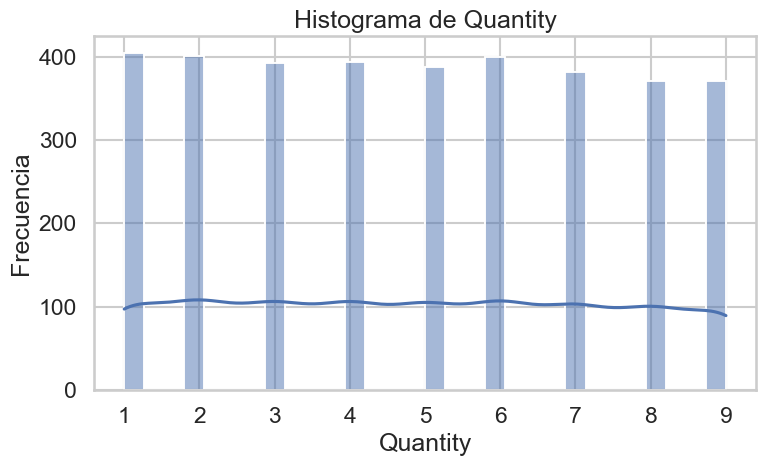

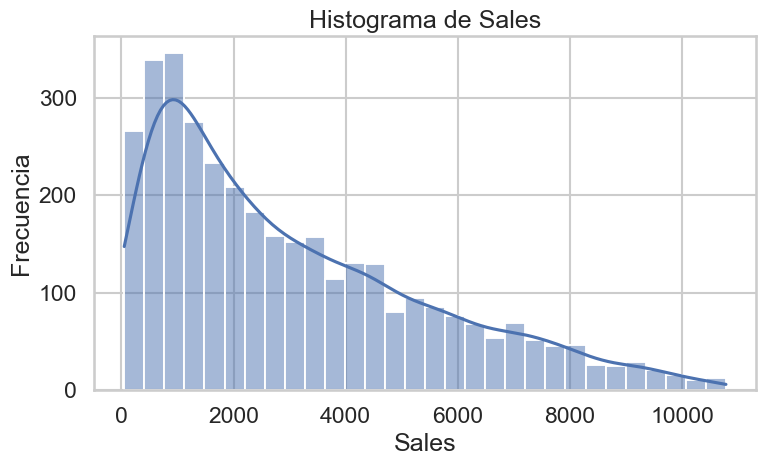

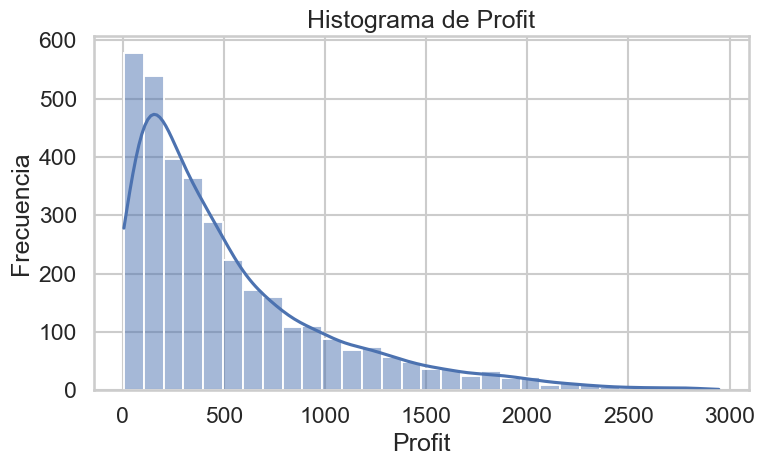

In [9]:
for col in variables_numericas:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"hist_{col.lower()}.png")
    plt.show()


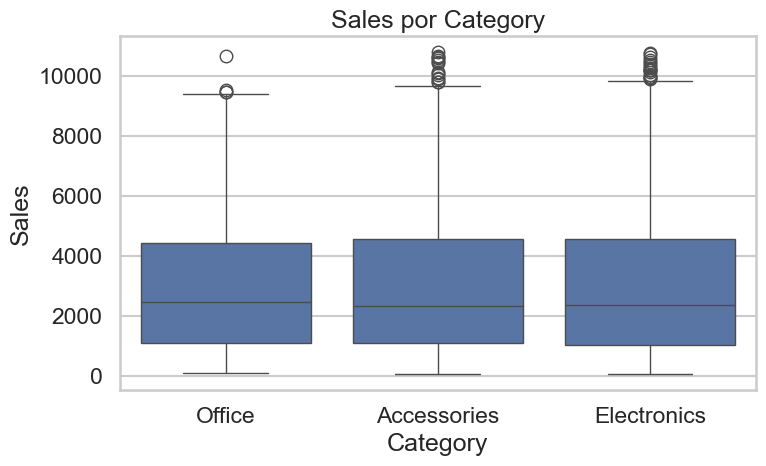

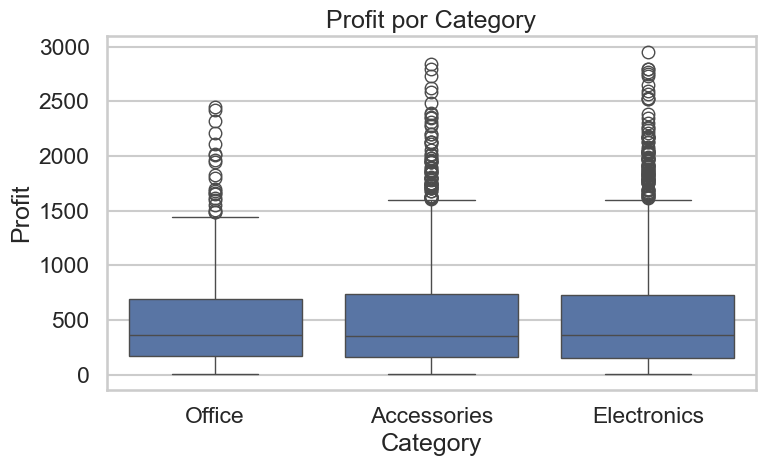

In [10]:
for col in ["Sales", "Profit"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="Category", y=col)
    plt.title(f"{col} por Category")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"box_{col.lower()}_by_category.png")
    plt.show()


In [11]:
# Outliers en Profit mediante IQR
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_profit = df[(df["Profit"] < lower_bound) | (df["Profit"] > upper_bound)]
len(outliers_profit), outliers_profit.head()


(184,
    Order Date     Product     Category Region  Quantity  Sales   Profit  Year  \
 12 2023-12-21      Tablet  Electronics  North         7   7462  2166.17  2023   
 32 2023-04-09      Laptop  Electronics  North         9  10773  1907.36  2023   
 55 2023-12-28  Headphones  Accessories   East         7   8155  1587.91  2023   
 60 2022-09-26  Headphones  Accessories  South         7   6895  1596.35  2022   
 92 2022-12-14      Camera  Electronics  South         7   7518  1655.91  2022   
 
     Month  
 12     12  
 32      4  
 55     12  
 60      9  
 92     12  )

## Celda 8 – Markdown (Lección 3)

## Lección 3: Correlación

Objetivos:
- Calcular la matriz de correlación entre variables numéricas.
- Visualizar las correlaciones con un heatmap.
- Analizar relaciones clave con scatterplots.


## Celda 9 – Code (correlación y gráficos)

In [12]:
corr_matrix = df[variables_numericas].corr(method="pearson")
corr_matrix


,Quantity,Sales,Profit
Quantity,1.000000,0.662468,0.560651
Sales,0.662468,1.000000,0.832826
Profit,0.560651,0.832826,1.000000


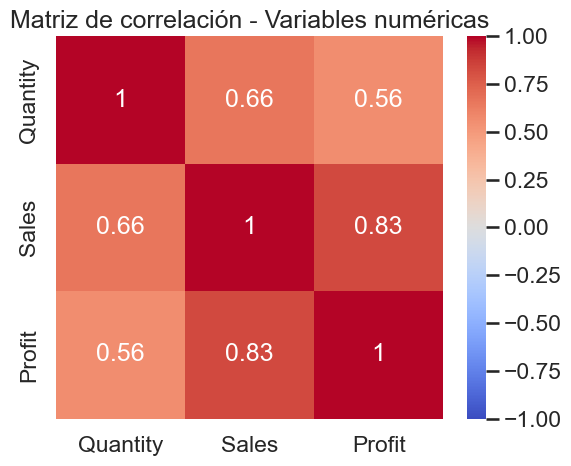

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación - Variables numéricas")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_correlation.png")
plt.show()


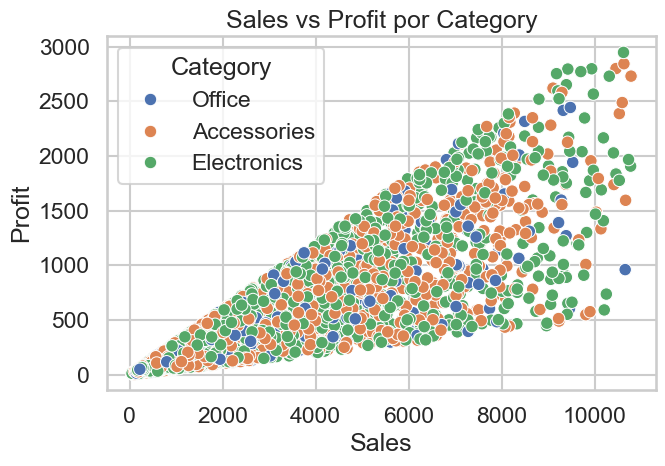

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Category")
plt.title("Sales vs Profit por Category")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_sales_profit_category.png")
plt.show()


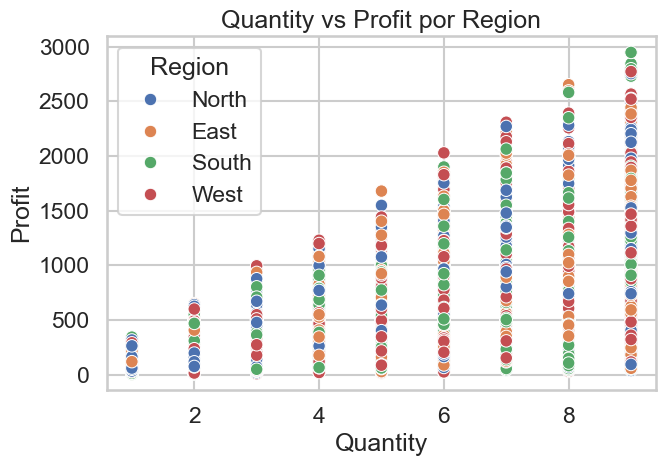

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Quantity", y="Profit", hue="Region")
plt.title("Quantity vs Profit por Region")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scatter_quantity_profit_region.png")
plt.show()


## Celda 10 – Markdown (Lección 4)

## Lección 4: Regresiones lineales

Objetivos:
- Ajustar un modelo de regresión lineal simple (Profit ~ Sales).
- Ajustar un modelo múltiple (Profit ~ Sales + Quantity).
- Interpretar R², coeficientes y significancia de predictores.


## Celda 11 – Code (regresiones)

In [16]:
y = df["Profit"]

# Modelo simple: Profit ~ Sales
X_simple = df[["Sales"]]
X_simple = sm.add_constant(X_simple)
model_simple = sm.OLS(y, X_simple).fit()
model_simple.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Profit   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     7918.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:16:36   Log-Likelihood:                -24676.
No. Observations:                3500   AIC:                         4.936e+04
Df Residuals:                    3498   BIC:                         4.937e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6173      7.549      0.347      0.729     -12.184      17.418
Sales          0.1721      0.002     88.985      0.000       0.168       0.176
==============================================================================
Omnibus:                      213.448   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              941.592
Skew:                           0.009   Prob(JB):                    3.44e-205
Kurtosis:                       5.541   Cond. No.                     6.25e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.25e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
# Modelo múltiple: Profit ~ Sales + Quantity
X_multi = df[["Sales", "Quantity"]]
X_multi = sm.add_constant(X_multi)
model_multi = sm.OLS(y, X_multi).fit()
model_multi.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Profit   R-squared:                       0.694
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     3961.
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:16:36   Log-Likelihood:                -24675.
No. Observations:                3500   AIC:                         4.936e+04
Df Residuals:                    3497   BIC:                         4.937e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.1053     10.191     -0.599      0.549     -26.086      13.876
Sales          0.1699      0.003     65.820      0.000       0.165       0.175
Quantity       3.1149      2.445      1.274      0.203      -1.679       7.909
==============================================================================
Omnibus:                      213.145   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              938.664
Skew:                           0.012   Prob(JB):                    1.49e-204
Kurtosis:                       5.537   Cond. No.                     8.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

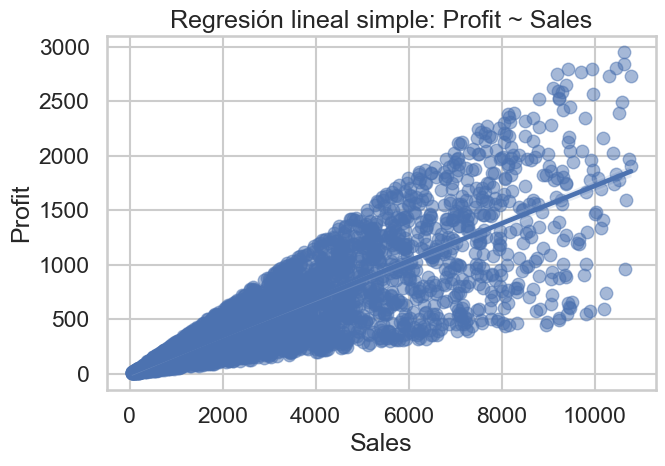

In [18]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="Sales", y="Profit", scatter_kws={"alpha": 0.5})
plt.title("Regresión lineal simple: Profit ~ Sales")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reg_simple_profit_sales.png")
plt.show()


## Celda 12 – Markdown (Lección 5)

## Lección 5: Análisis visual de datos con Seaborn

Objetivos:
- Representar relaciones complejas y distribuciones.
- Usar pairplot, violinplot, jointplot y FacetGrid.
- Documentar insights visuales relevantes.


## Celda 13 – Code (visualización avanzada)

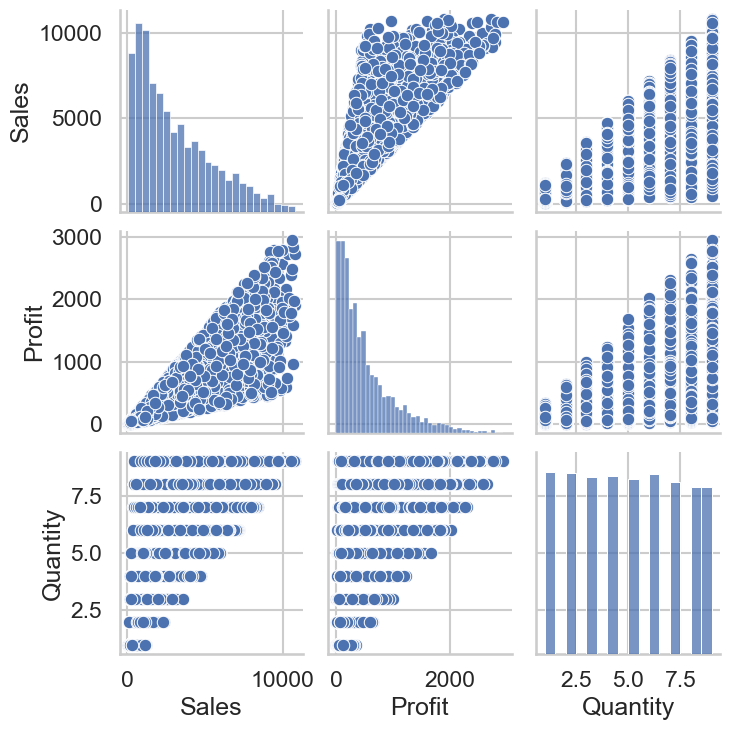

In [19]:
sns.pairplot(df[["Sales", "Profit", "Quantity"]])
plt.savefig(FIGURES_DIR / "pairplot_numeric.png")
plt.show()


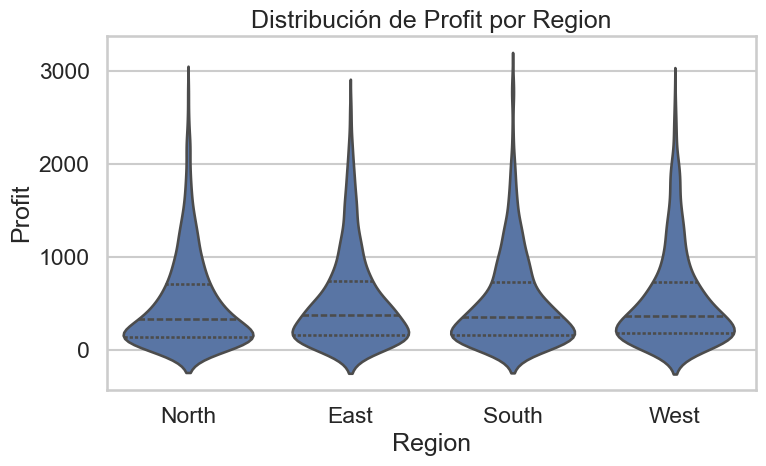

In [20]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Region", y="Profit", inner="quartile")
plt.title("Distribución de Profit por Region")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "violin_profit_region.png")
plt.show()


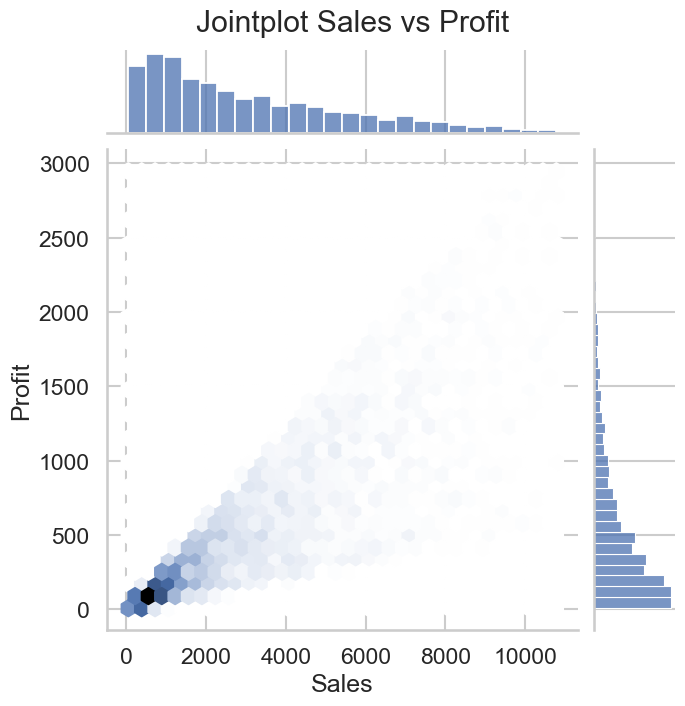

In [21]:
jp = sns.jointplot(data=df, x="Sales", y="Profit", kind="hex", height=7)
jp.fig.suptitle("Jointplot Sales vs Profit", y=1.02)
jp.savefig(FIGURES_DIR / "joint_sales_profit.png")
plt.show()


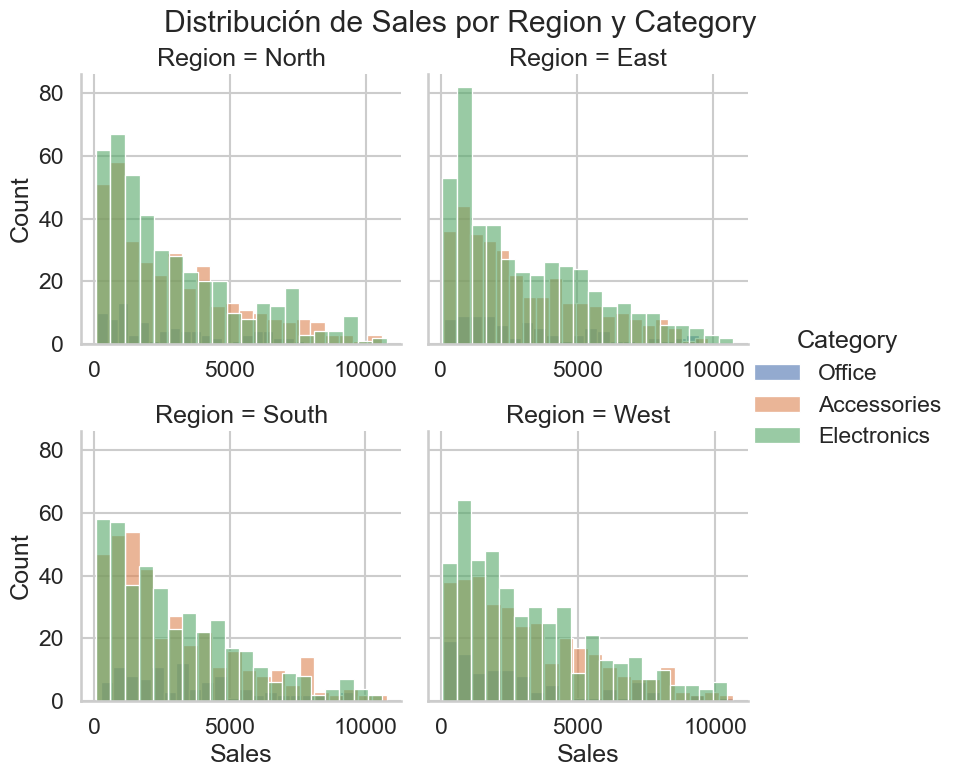

In [22]:
g = sns.FacetGrid(df, col="Region", hue="Category", col_wrap=2, height=4, sharex=False)
g.map(sns.histplot, "Sales", bins=20, alpha=0.6)
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Distribución de Sales por Region y Category")
g.savefig(FIGURES_DIR / "facet_sales_region_category.png")
plt.show()


## Celda 14 – Markdown (Lección 6)

## Lección 6: Visualizaciones personalizadas con Matplotlib

Objetivos:
- Crear figuras con múltiples subplots.
- Personalizar títulos, etiquetas y leyendas.
- Generar un resumen gráfico para el informe final.


## Celda 15 – Code (subplots resumen)

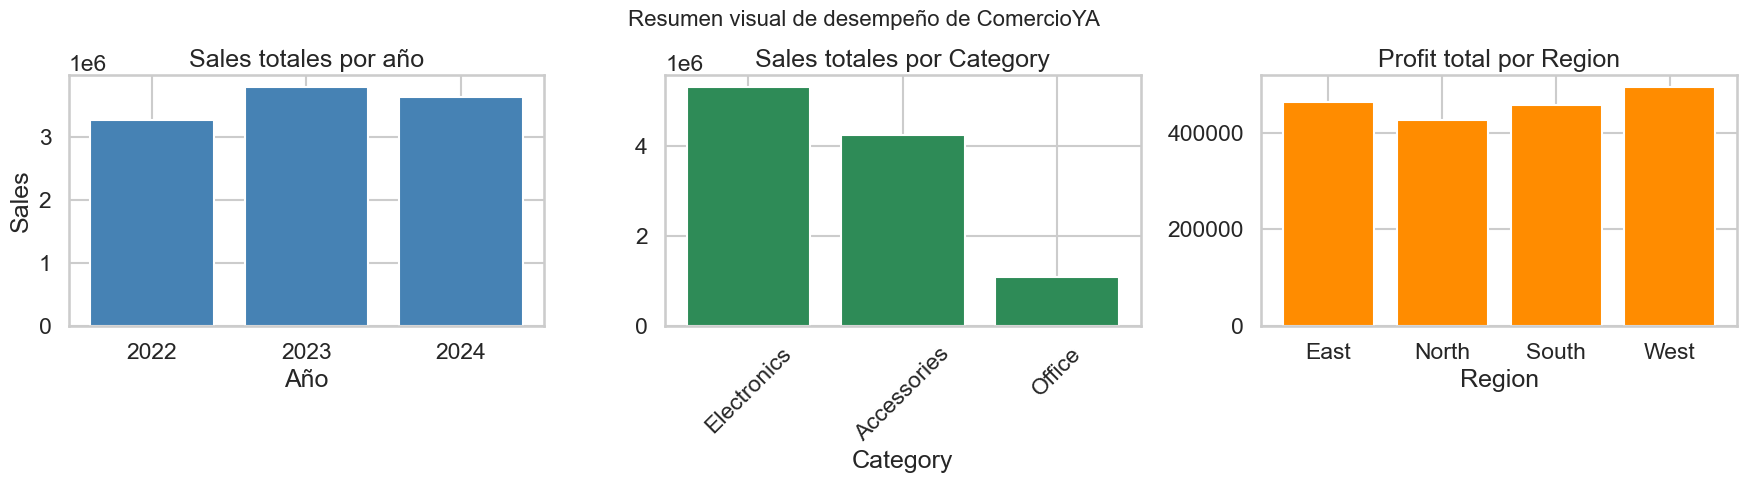

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sales por año
sales_by_year = df.groupby("Year")["Sales"].sum()
axes[0].bar(sales_by_year.index, sales_by_year.values, color="steelblue")
axes[0].set_title("Sales totales por año")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Sales")

# Sales por Category
sales_by_cat = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
axes[1].bar(sales_by_cat.index, sales_by_cat.values, color="seagreen")
axes[1].set_title("Sales totales por Category")
axes[1].set_xlabel("Category")
axes[1].tick_params(axis='x', rotation=45)

# Profit por Region
profit_by_region = df.groupby("Region")["Profit"].sum()
axes[2].bar(profit_by_region.index, profit_by_region.values, color="darkorange")
axes[2].set_title("Profit total por Region")
axes[2].set_xlabel("Region")

fig.suptitle("Resumen visual de desempeño de ComercioYA", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig(FIGURES_DIR / "summary_subplots.png")
plt.show()


## Celda 16 – Markdown (cierre)

## Conclusiones y próximos pasos

___

En este análisis exploratorio identificamos que las ventas y la ganancia se concentran en unas pocas combinaciones de **categoría**, **producto** y **región**, mientras que el resto del portafolio tiene un aporte menor y más disperso. Las categorías de **Electronics** y accesosorios tecnológicos muestran operaciones frecuentes con montos y márgenes variados, lo que evidencia oportunidades de optimización tanto en precios como en costos. 

Las correlaciones entre **Sales** y **Profit** son positivas pero no perfectas, lo que indica que mayores ventas no siempre implican una rentabilidad proporcional; esto se ve reforzado por la presencia de outliers con altos ingresos pero márgenes moderados. El modelo de regresión lineal confirma que las ventas explican una parte relevante de la variación en la ganancia, y que la cantidad vendida puede aportar información adicional, aunque su impacto depende del tipo de producto y la región.

Desde una perspectiva comercial, ComercioYA podría priorizar los productos y categorías con mejor combinación de volumen y margen, revisar aquellos con muchas ventas pero baja ganancia y diseñar campañas específicas por región para potenciar los segmentos más rentables. Como trabajo futuro, se recomienda incorporar datos a nivel de cliente (frecuencia de compra, devoluciones, reseñas) para enriquecer el análisis y construir modelos más avanzados de segmentación y predicción.

---

